<a href="https://colab.research.google.com/github/allnlk/ML/blob/main/%D0%9B%D0%914_%D0%9A%D1%83%D0%B1%D1%80%D0%B0%D0%BA_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.

In [2]:
import os
import warnings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.

In [3]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))

display(df.head())

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
print("Розмір датасету:", df.shape)
print("Кількість об'єктів:", df.shape[0], "| Кількість ознак (разом з price):", df.shape[1])
print("\nНазви стовпців:")
print(df.columns.tolist())
print()
df.info()

Розмір датасету: (205, 26)
Кількість об'єктів: 205 | Кількість ознак (разом з price): 26

Назви стовпців:
['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel     

In [5]:
df.dtypes.value_counts()

,count
object,10
int64,8
float64,8


In [6]:
print("Цільова змінна: price")
df["price"].describe()

Цільова змінна: price


,price
count,205.000000
mean,13276.710571
std,7988.852332
min,5118.000000
25%,7788.000000
50%,10295.000000
75%,16503.000000
max,45400.000000


In [7]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [8]:
df.describe(include=["object"])

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
count,205,205,205,205,205,205,205,205,205,205
unique,147,2,2,2,5,3,2,7,7,8
top,peugeot 504,gas,std,four,sedan,fwd,front,ohc,four,mpfi
freq,6,185,168,115,96,120,202,148,159,94


**car_ID** — Унікальний ідентифікатор кожного автомобіля.

**symboling** — Оцінка рівня ризику авто.

**CarName** — Назва виробника та моделі автомобіля.

**fueltype** — Тип пального .

**aspiration** — Тип впуску двигуна.

**doornumber** — Кількість дверей.

**carbody** — Тип кузова.

**drivewheel** — Тип приводу.

**enginelocation** — Розташування двигуна.

**wheelbase** — Колісна база автомобіля.

**carlength** — Довжина автомобіля.

**carwidth** — Ширина автомобіля.

**carheight** — Висота автомобіля.

**curbweight** — Споряджена маса автомобіля без пасажирів і вантажу.

**enginetype** — Тип двигуна.

**cylindernumber** — Кількість циліндрів у двигуні.

**enginesize** — Об'єм/розмір двигуна.

**fuelsystem** — Система подачі пального.

**boreratio** — Співвідношення діаметра циліндра до ходу поршня.

**stroke** — Хід поршня всередині двигуна.

**compressionratio** — Ступінь стиснення двигуна.

**horsepower** — Потужність двигуна.

**peakrpm** — Максимальні оберти двигуна на хвилину.

**citympg** — Витрата пального в міському циклі.

**highwaympg** — Витрата пального на трасі.

**price** — Ціна автомобіля в доларах.

## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.

In [9]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [10]:
df.drop(columns=['car_ID']).duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

,0
car_ID,205
symboling,6
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
wheelbase,53


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.

In [12]:
df['CarName'].value_counts()

,count
CarName,
peugeot 504,6
toyota corolla,6
toyota corona,6
subaru dl,4
mitsubishi outlander,3
...,...
volkswagen super beetle,1
volkswagen rabbit custom,1
volvo 245,1


In [13]:
car_ids = df["car_ID"].copy()

df["brand"] = (
    df["CarName"]
    .str.lower()
    .str.split()
    .str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vwi": "volkswagen",
        "vw": "volkswagen",
        "alfa-romero": "alfa-romeo",
    })
)

df = df.drop(columns=["car_ID", "CarName"])

print("Кількість виробників:", df["brand"].nunique())
print(sorted(df["brand"].unique()))

Кількість виробників: 22
['alfa-romeo', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'mazda', 'mercury', 'mitsubishi', 'nissan', 'peugeot', 'plymouth', 'porsche', 'renault', 'saab', 'subaru', 'toyota', 'volkswagen', 'volvo']


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.

,skewness
compressionratio,2.610862
enginesize,1.947655
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
symboling,0.211072


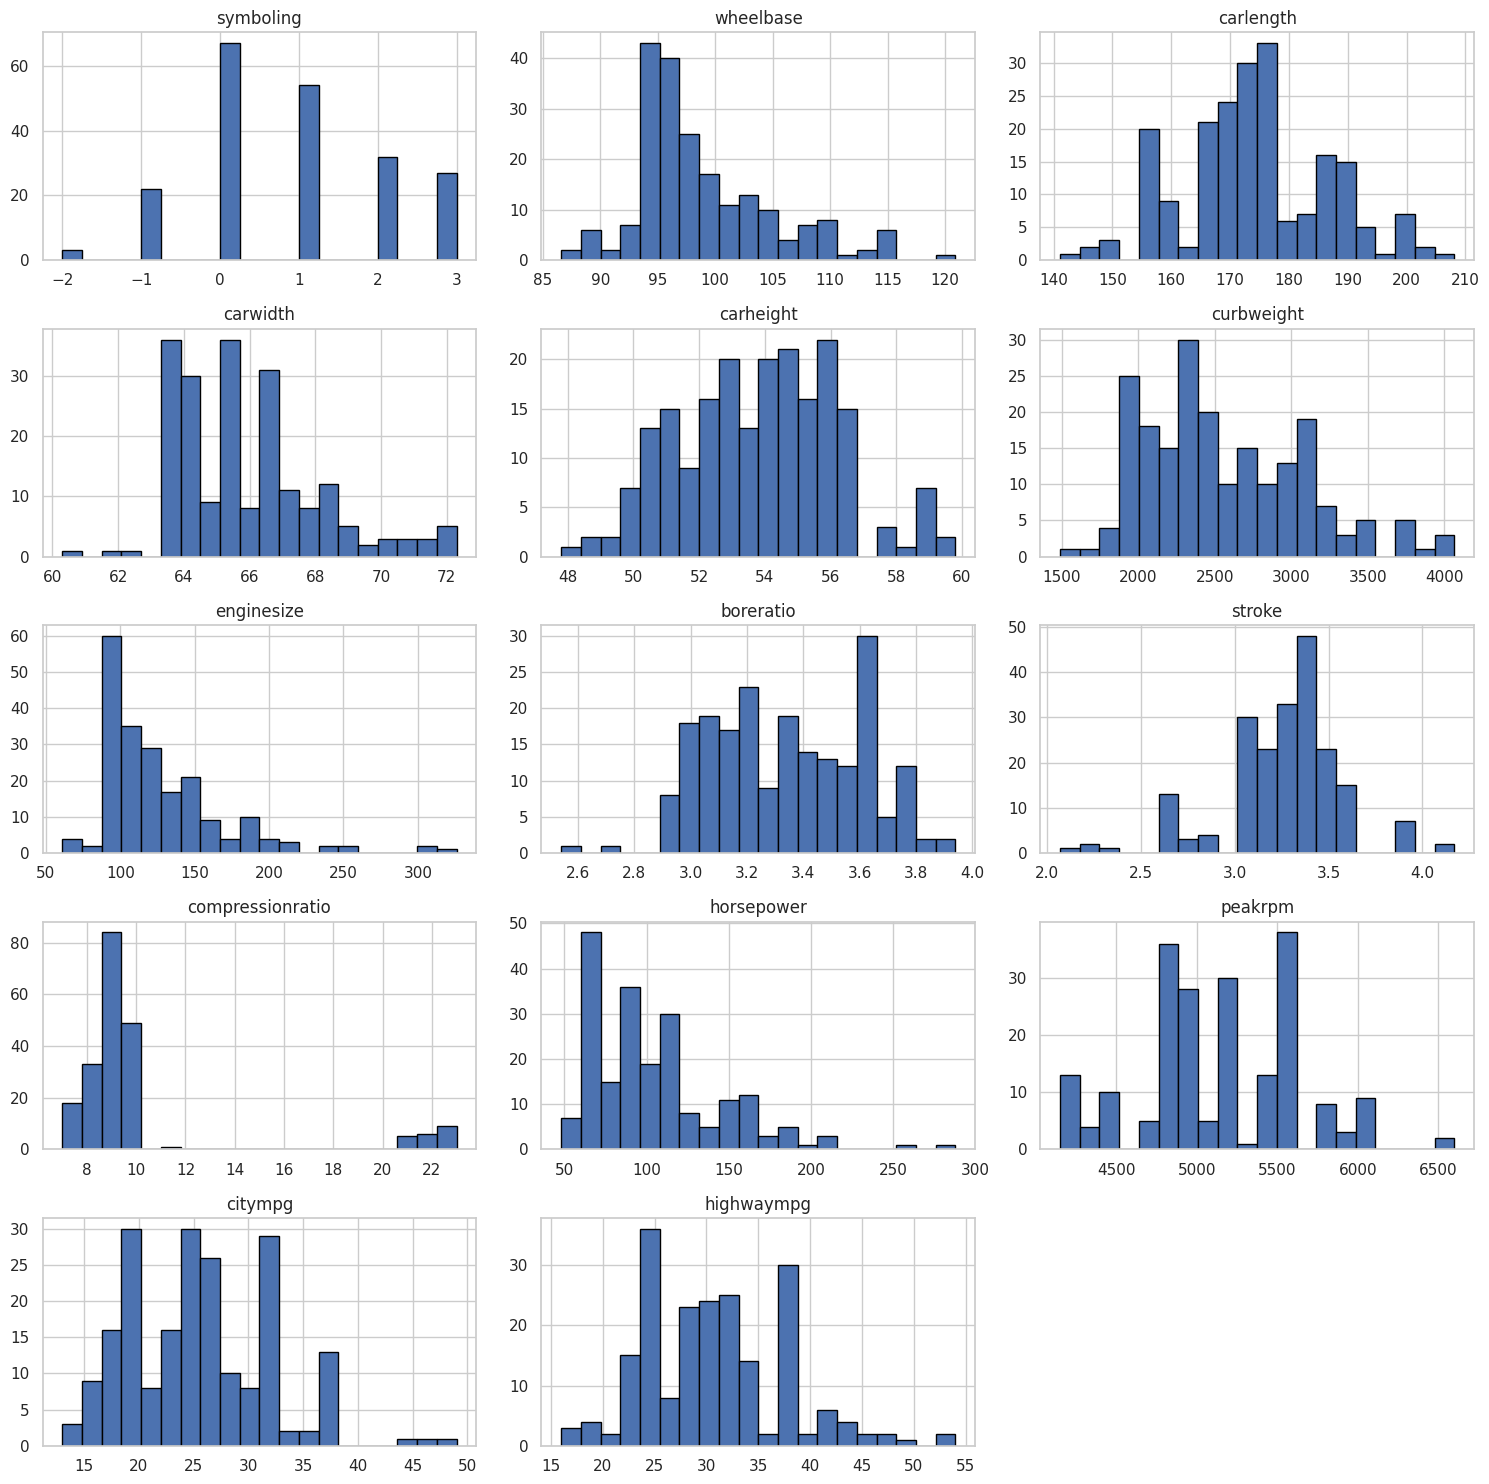

In [14]:
numeric_initial = df.select_dtypes(include=np.number).columns.drop('price', errors='ignore')

skew_initial = df[numeric_initial].skew().sort_values(key=np.abs, ascending=False)
display(skew_initial.to_frame('skewness'))


n_cols = 3
n_rows = int(np.ceil(len(numeric_initial) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_initial):
    df[col].hist(ax=axes[i], bins=20, edgecolor="black")
    axes[i].set_title(col)

for j in range(len(numeric_initial), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Висновок: найбільш асиметричні ознаки: compressionratio (≈2.61), enginesize (≈1.95), horsepower (≈1.41), wheelbase (≈1.05) та carwidth (≈0.90). Усі вони правосторонньо асиметричні. Ознаки boreratio, carheight, peakrpm і carlength близькі до симетричних. Для лінійних моделей це причина застосувати Yeo–Johnson.

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.

In [16]:
X = df.drop(columns=["price"])
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_car_ids = car_ids.loc[X_train.index]
test_car_ids = car_ids.loc[X_test.index]

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (164, 24) | Test: (41, 24)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.

In [18]:
class IQRClipper(BaseEstimator, TransformerMixin):

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1, q3 = X.quantile(0.25), X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - self.factor * iqr).to_numpy()
        self.upper_ = (q3 + self.factor * iqr).to_numpy()
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)

continuous_initial = [
    c for c in X_train.select_dtypes(include=np.number).columns if c != "symboling"
]

clipper_check = IQRClipper().fit(X_train[continuous_initial])

outliers_df = pd.DataFrame({
    "Ознака": continuous_initial,
    "Нижня межа": clipper_check.lower_,
    "Верхня межа": clipper_check.upper_,
    "Викидів у train": [
        ((X_train[c] < lo) | (X_train[c] > up)).sum()
        for c, lo, up in zip(continuous_initial, clipper_check.lower_, clipper_check.upper_)
    ],
    "Викидів у test (за межами train)": [
        ((X_test[c] < lo) | (X_test[c] > up)).sum()
        for c, lo, up in zip(continuous_initial, clipper_check.lower_, clipper_check.upper_)
    ],
}).sort_values("Викидів у train", ascending=False).reset_index(drop=True)

display(outliers_df)

X_train_clipped = pd.DataFrame(
    clipper_check.transform(X_train[continuous_initial]),
    columns=continuous_initial, index=X_train.index,
)
changed = (X_train_clipped != X_train[continuous_initial].astype(float)).sum().sum()
rows_changed = (X_train_clipped != X_train[continuous_initial].astype(float)).any(axis=1).sum()
print(f"Обмежено {changed} значень у {rows_changed} з {len(X_train)} рядків train (жодного рядка не видалено).")

,Ознака,Нижня межа,Верхня межа,Викидів у train,Викидів у test (за межами train)
0,compressionratio,7.4000,10.6000,20,8
1,stroke,2.6600,3.8600,16,4
2,carwidth,60.4250,70.4250,10,2
3,horsepower,4.7500,182.7500,7,1
4,enginesize,33.5000,205.5000,7,3
5,wheelbase,83.1000,113.5000,6,1
6,peakrpm,3750.0000,6550.0000,2,0
7,highwaympg,11.5000,47.5000,1,2
8,boreratio,2.5650,4.1250,1,0
9,curbweight,998.6250,4103.6250,0,0


Обмежено 70 значень у 50 з 164 рядків train (жодного рядка не видалено).


Висновок: Потенційні викиди за IQR є переважно в compressionratio, stroke, carwidth, enginesize, horsepower та wheelbase. Рядки не видаляються: вибірка мала , і значна частина «викидів» — це реальні автомобілі, а не помилки вимірювання. Тому застосовано winsorization: значення обмежуються межами Q1 − 1.5·IQR` та `Q3 + 1.5·IQR, обчисленими за train. Для цього написано трансформер IQRClipper, який навчається лише на train і стає першим кроком обробки неперервних ознак у Pipeline. price для визначення меж не використовується.

## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.

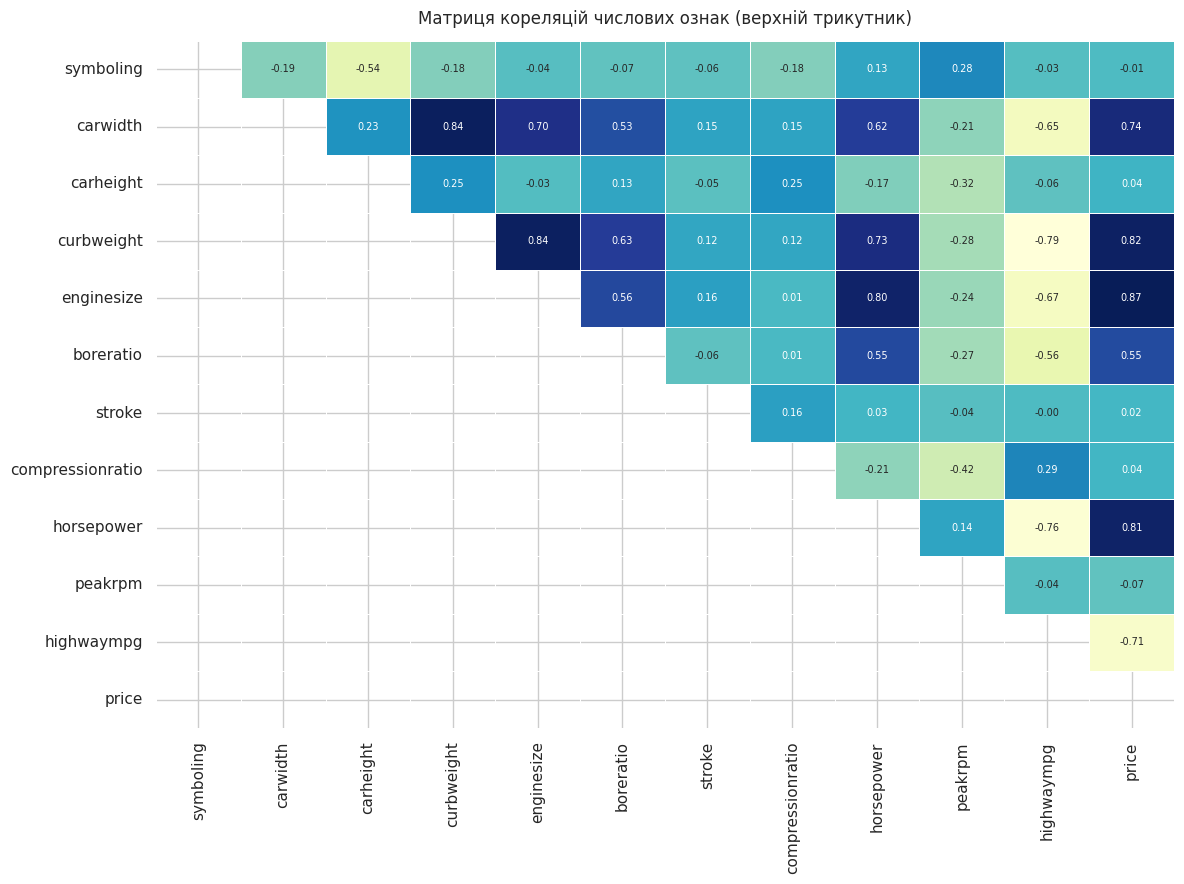

Пари ознак з високою кореляцією (|r| > 0.85):


In [22]:
train_data = X_train.select_dtypes(include=np.number).copy()
train_data["price"] = y_train

corr_matrix = train_data.corr()
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    annot_kws={"size": 7},
    linewidths=0.5,
    cbar=False
)

plt.title("Матриця кореляцій числових ознак (верхній трикутник)", fontsize=12, pad=12)
plt.tight_layout()
plt.show()

THRESHOLD = 0.85
feat_corr = corr_matrix.drop(index="price", columns="price").abs()
cols = feat_corr.columns

pairs = []
for i, a in enumerate(cols):
    for b in cols[i + 1:]:
        if feat_corr.loc[a, b] > THRESHOLD:
            pairs.append((a, b, feat_corr.loc[a, b]))

pairs.sort(key=lambda t: -t[2])

print(f"Пари ознак з високою кореляцією (|r| > {THRESHOLD}):")
to_drop = []
for a, b, r in pairs:
    print(f"  {a} -- {b}: r = {r:.2f}")

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.

In [24]:
continuous_cols = [
    c for c in X_train.select_dtypes(include=np.number).columns if c != "symboling"
]
ordinal_numeric_cols = ["symboling"]
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Неперервні:", continuous_cols)
print("Дискретна:", ordinal_numeric_cols)
print("Категоріальні:", categorical_cols)

numeric_pipeline = Pipeline(steps=[
    ("clip", IQRClipper(factor=1.5)),
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", numeric_pipeline, continuous_cols),
        ("ordinal", ordinal_pipeline, ordinal_numeric_cols),
        ("categorical", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

Неперервні: ['carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
Дискретна: ['symboling']
Категоріальні: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.

In [26]:
skew_before = X_train[continuous_cols].skew()

clipped = pd.DataFrame(
    IQRClipper().fit_transform(X_train[continuous_cols]),
    columns=continuous_cols, index=X_train.index,
)
skew_clipped = clipped.skew()

num_check = clone(numeric_pipeline)
transformed = pd.DataFrame(
    num_check.fit_transform(X_train[continuous_cols]),
    columns=continuous_cols, index=X_train.index,
)
skew_after = transformed.skew()

skew_cmp = pd.DataFrame({
    "До обробки": skew_before,
    "Після обмеження викидів": skew_clipped,
    "Після повної обробки": skew_after,
}).sort_values("До обробки", key=np.abs, ascending=False)

display(skew_cmp)
print("Середній |skew| до:   ", round(skew_before.abs().mean(), 3))
print("Середній |skew| після:", round(skew_after.abs().mean(), 3))

,До обробки,Після обмеження викидів,Після повної обробки
compressionratio,2.737494,0.055710,0.004872
enginesize,2.049555,0.962394,0.044834
horsepower,1.546398,0.850735,0.066280
carwidth,1.014691,0.730804,0.000000
stroke,-0.755037,-0.397600,0.015846
curbweight,0.712433,0.712433,0.049894
highwaympg,0.289597,0.243761,-0.012188
peakrpm,0.067295,0.039773,-0.003589
boreratio,0.050359,0.062963,-0.005941
carheight,0.028154,0.028154,-0.005170


Середній |skew| до:    0.925
Середній |skew| після: 0.021


Висновок: після обмеження викидів і перетворення Yeo–Johnson коефіцієнти асиметрії неперервних ознак упали до значень, близьких до нуля. Трансформація ефективна. Після StandardScaler ознаки мають середнє 0 і стандартне відхилення 1, що важливо для Ridge/Lasso і особливо для SVR.

## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.

In [28]:
estimators = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=20000),
    "Random Forest": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

models = {
    name: Pipeline(steps=[("preprocess", clone(preprocessor)), ("model", estimator)])
    for name, estimator in estimators.items()
}
svr_pipeline = Pipeline(steps=[
    ("preprocess", clone(preprocessor)),
    ("model", TransformedTargetRegressor(regressor=SVR(kernel="rbf"), transformer=StandardScaler())),
])
models["SVR"] = GridSearchCV(
    svr_pipeline,
    param_grid={
        "model__regressor__C": [1, 10, 100, 1000],
        "model__regressor__epsilon": [0.01, 0.1, 0.2],
        "model__regressor__gamma": ["scale", 0.01, 0.03],
    },
    cv=5, scoring="r2", n_jobs=-1,
)

for name, model in models.items():
    model.fit(X_train, y_train)
    print("Навчено:", name)

print("\nНайкращі параметри SVR:", models["SVR"].best_params_)
print("CV R² SVR (train):", round(models["SVR"].best_score_, 3))

Навчено: Linear Regression
Навчено: Ridge
Навчено: Lasso
Навчено: Random Forest
Навчено: Gradient Boosting
Навчено: SVR

Найкращі параметри SVR: {'model__regressor__C': 100, 'model__regressor__epsilon': 0.01, 'model__regressor__gamma': 0.01}
CV R² SVR (train): 0.917


Висновок: Для кожної моделі побудовано єдиний Pipeline передобробка + модель з однаковою схемою підготовки даних, тому порівняння коректне. Окремо про SVR: у першій версії він давав від'ємний R², бо ціна в доларах десятки тисяч не масштабувалась, і модель із параметрами за замовчуванням фактично прогнозувала майже константу. Виправлення: стандартизація цільової змінної + підбір C, epsilon, gamma через 5-fold крос-валідацію на train тест не використовується.

## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.

In [29]:
results = []
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    predictions[name] = y_pred
    mse = mean_squared_error(y_test, y_pred)
    results.append({
        "Model": name,
        "R^2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE, %": mean_absolute_percentage_error(y_test, y_pred) * 100,
        "R^2 train": r2_score(y_train, y_pred_train),
    })

results_df = (
    pd.DataFrame(results)
    .sort_values("R^2", ascending=False)
    .reset_index(drop=True)
)
results_df["R^2 train - test"] = results_df["R^2 train"] - results_df["R^2"]

display(
    results_df.style.format({
        "R^2": "{:.3f}", "MAE": "{:,.0f}", "MSE": "{:,.0f}", "RMSE": "{:,.0f}",
        "MAPE, %": "{:.2f}%", "R^2 train": "{:.3f}", "R^2 train - test": "{:.3f}",
    })
)

,Model,R^2,MAE,MSE,RMSE,"MAPE, %",R^2 train,R^2 train - test
0,Random Forest,0.957,"1,235","3,359,049","1,833",9.06%,0.986,0.029
1,SVR,0.938,"1,676","4,916,918","2,217",13.08%,0.992,0.055
2,Gradient Boosting,0.935,"1,591","5,136,880","2,266",10.62%,0.993,0.059
3,Linear Regression,0.879,"2,156","9,518,236","3,085",16.38%,0.960,0.080
4,Lasso,0.878,"2,105","9,612,671","3,100",15.13%,0.960,0.081
5,Ridge,0.854,"2,367","11,542,488","3,397",18.19%,0.948,0.094


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.

Logistic Regression є моделлю класифікації вона прогнозує ймовірності належності до скінченного набору дискретних класів і повертає мітку класу. Ціна автомобіля неперервна величина: у датасеті 189 унікальних цін на 205 авто, тому «класів» було б майже стільки ж, скільки об'єктів, по одному прикладу на клас. Така модель не змогла б спрогнозувати жодного значення, якого не було в train, ігнорувала б порядок і відстань між цінами  і не мала б змістовної метрики якості.

Прогнозування price — задача регресії.
Використані моделі — Linear, Ridge, Lasso, Random Forest, Gradient Boosting та SVR — регресійні: вони повертають числове значення, а навчаються мінімізацією похибки між фактичною і прогнозованою ціною.

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.

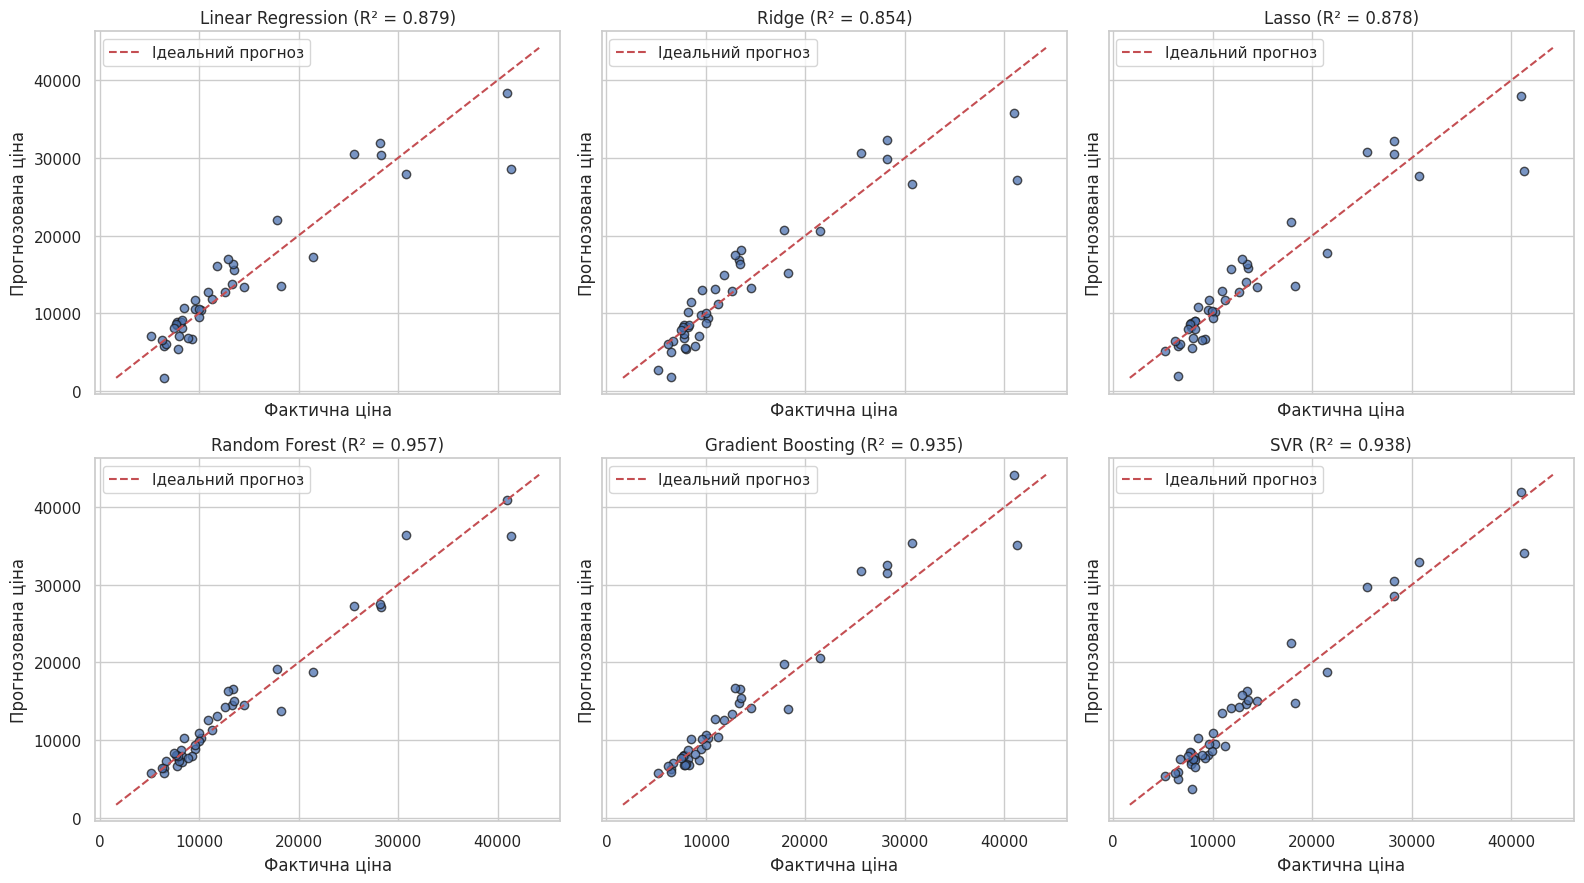

,Model,car_ID,Фактична,Прогноз,Абс. помилка
0,Linear Regression,17,"41,315","28,634","12,681"
1,Linear Regression,68,"25,552","30,520","4,968"
2,Ridge,17,"41,315","27,195","14,120"
3,Ridge,74,"40,960","35,825","5,135"
4,Lasso,17,"41,315","28,267","13,048"
5,Lasso,68,"25,552","30,742","5,190"
6,Random Forest,16,"30,760","36,473","5,713"
7,Random Forest,17,"41,315","36,349","4,966"
8,Gradient Boosting,68,"25,552","31,832","6,280"
9,Gradient Boosting,17,"41,315","35,196","6,119"


In [30]:
lims = [min(y_test.min(), min(p.min() for p in predictions.values())),
        max(y_test.max(), max(p.max() for p in predictions.values()))]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.75, edgecolor="k")
    ax.plot(lims, lims, "r--", label="Ідеальний прогноз")
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f"{name} (R² = {r2:.3f})")
    ax.set_xlabel("Фактична ціна")
    ax.set_ylabel("Прогнозована ціна")
    ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

rows = []
for name, y_pred in predictions.items():
    err = pd.Series(np.abs(y_test.to_numpy() - y_pred), index=y_test.index)
    for idx in err.nlargest(2).index:
        rows.append({
            "Model": name, "car_ID": test_car_ids.loc[idx],
            "Фактична": y_test.loc[idx],
            "Прогноз": y_pred[list(y_test.index).index(idx)],
            "Абс. помилка": err.loc[idx],
        })
display(pd.DataFrame(rows).style.format({"Фактична": "{:,.0f}", "Прогноз": "{:,.0f}", "Абс. помилка": "{:,.0f}"}))

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.

In [31]:
rf_model = models["Random Forest"]

sample_X = X_test.sample(10, random_state=42)
sample_y = y_test.loc[sample_X.index]
sample_pred = rf_model.predict(sample_X)

sample_table = pd.DataFrame({
    "car_ID": test_car_ids.loc[sample_X.index].values,
    "Фактична ціна": sample_y.values,
    "Прогнозована ціна": sample_pred,
})
sample_table["Абсолютна помилка"] = (sample_table["Фактична ціна"] - sample_table["Прогнозована ціна"]).abs()
sample_table["Абс. відсоткова помилка, %"] = sample_table["Абсолютна помилка"] / sample_table["Фактична ціна"] * 100

display(
    sample_table.style.format({
        "Фактична ціна": "{:,.0f}", "Прогнозована ціна": "{:,.0f}",
        "Абсолютна помилка": "{:,.0f}", "Абс. відсоткова помилка, %": "{:.1f}%",
    })
)
print(f"Середня абсолютна помилка на вибірці: {sample_table['Абсолютна помилка'].mean():,.0f}")
print(f"Середня відсоткова помилка на вибірці: {sample_table['Абс. відсоткова помилка, %'].mean():.1f}%")

,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,"Абс. відсоткова помилка, %"
0,26,"6,692","7,300",608,9.1%
1,176,"9,988","10,908",920,9.2%
2,148,"10,198","10,267",69,0.7%
3,17,"41,315","36,349","4,966",12.0%
4,69,"28,248","27,131","1,117",4.0%
5,147,"7,463","8,293",830,11.1%
6,144,"9,960","9,837",123,1.2%
7,85,"14,489","14,526",37,0.3%
8,195,"12,940","16,360","3,420",26.4%
9,160,"7,788","7,878",90,1.2%


Середня абсолютна помилка на вибірці: 1,218
Середня відсоткова помилка на вибірці: 7.5%


 Для 10 випадкових автомобілів із тестової вибірки Random Forest у більшості випадків дає прогноз із помилкою в межах кількох відсотків; для окремих авто помилка більша. Оскільки вибірка складається лише з 10 об'єктів, її середні помилки можуть відрізнятися від метрик на всій тестовій вибірці , тому надійнішою оцінкою якості є саме повна таблиця метрик.

## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.

In [32]:
best = results_df.iloc[0]
worst = results_df.iloc[-1]
print(f"Найкраща модель: {best['Model']}  R²={best['R^2']:.3f}, MAE={best['MAE']:,.0f}$, "
      f"RMSE={best['RMSE']:,.0f}$, MAPE={best['MAPE, %']:.1f}%")
print(f"Найгірша модель: {worst['Model']}  R²={worst['R^2']:.3f}, MAE={worst['MAE']:,.0f}$, "
      f"MAPE={worst['MAPE, %']:.1f}%")
print(f"Середня ціна в test: {y_test.mean():,.0f}$  (MAE найкращої моделі = "
      f"{best['MAE'] / y_test.mean():.1%} від середньої ціни)")
print()
print("Розрив R² train - test (ознака перенавчання):")
print(results_df[["Model", "R^2 train", "R^2", "R^2 train - test"]].round(3).to_string(index=False))

Найкраща модель: Random Forest  R²=0.957, MAE=1,235$, RMSE=1,833$, MAPE=9.1%
Найгірша модель: Ridge  R²=0.854, MAE=2,367$, MAPE=18.2%
Середня ціна в test: 13,490$  (MAE найкращої моделі = 9.2% від середньої ціни)

Розрив R² train - test (ознака перенавчання):
            Model  R^2 train   R^2  R^2 train - test
    Random Forest      0.986 0.957             0.029
              SVR      0.992 0.938             0.055
Gradient Boosting      0.993 0.935             0.059
Linear Regression      0.960 0.879             0.080
            Lasso      0.960 0.878             0.081
            Ridge      0.948 0.854             0.094


1. **Порівняння моделей.** Найкращі результати за всіма метриками  показують ансамблеві моделі на деревах, насамперед Random Forest, далі Gradient Boosting. Лінійні моделі (Linear, Ridge, Lasso) трохи слабші: вони не враховують нелінійні залежності й взаємодії ознак. Ridge/Lasso з alpha=1.0 суттєво не покращують Linear Regression, бо після масштабування і відбору ознак мультиколінеарність уже невелика. SVR після масштабування цілі та підбору гіперпараметрів перестав бути аутсайдером із від'ємним R², але лишається чутливим до налаштувань.
2. **Метрики.** R² показує частку поясненої дисперсії; MAE і RMSE дають середню помилку в доларах; MAPE показує помилку у відсотках від ціни, що зручно для порівняння дешевих і дорогих авто. Порядок моделей за різними метриками загалом збігається.
3. **Величина похибок.** Порівняйте MAE найкращої моделі з середньою ціною : для Random Forest це порядку 10% від середньої ціни, для лінійних моделей — більше. Найбільші помилки припадають на дорогі та рідкісні авто.
4. **Перенавчання.** Ансамблеві моделі показують високий R² на train і помітно нижчий на test, тобто є помірні ознаки перенавчання, типові для Random Forest/Gradient Boosting на малих вибірках. Однак на test вони однаково найточніші, тому це не заважає їх використовувати. У лінійних моделей розрив менший. Через малий розмір test оцінки нестабільні, і для надійнішого висновку варто використати крос-валідацію.
5. **Вплив передобробки.** Вилучення car_ID, виділення brand з CarName, відбір ознак за кореляцією, обмеження викидів та Yeo–Johnson зменшили асиметрію ознак майже до нуля й послабили мультиколінеарність, що найбільше допомагає лінійним моделям і SVR. Дерева малочутливі до масштабу й форми розподілу, тому для них вплив менший. Усі параметри передобробки визначались лише за train, тому метрики на test не містять витоку даних.

## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.